In [41]:
# ── Core imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='Set2')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [18]:
import pandas as pd
df = pd.read_csv("/content/Lab_Exam_binary_classification_dataset.csv")
df.head()

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [30]:
# ── 1.3  Missing values ───────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])
print(f'\nTotal rows with any missing value: {df.isnull().any(axis=1).sum()}')

# Drop rows where Target is missing (cannot train/evaluate without a label)
df = df.dropna(subset=['Target']).copy()
print(f'\nRows retained after dropping missing Target: {len(df)}')

Missing values per column:
Target    20
dtype: int64

Total rows with any missing value: 20

Rows retained after dropping missing Target: 1000


In [31]:
# ── 1.4  Outlier Detection ────────────────────────────────────────────────────
# Feature1 IQR-based check
Q1 = df['Feature1'].quantile(0.25)
Q3 = df['Feature1'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
outliers_f1 = df[df['Feature1'] > upper_fence]
print(f'Feature1 IQR upper fence: {upper_fence:.4f}')
print(f'Outlier rows in Feature1:')
print(outliers_f1[['Feature1', 'Feature2', 'Target']])

# Remove the extreme outlier before modelling
df = df[df['Feature1'] <= upper_fence].copy()
print(f'\nRows after outlier removal: {len(df)}')

Feature1 IQR upper fence: 2.4187
Outlier rows in Feature1:
     Feature1  Feature2 Target
132   10000.0       620     No

Rows after outlier removal: 999


Class counts:
Target
No     784
Yes    215
Name: count, dtype: int64

Class balance (Yes %): 21.5%


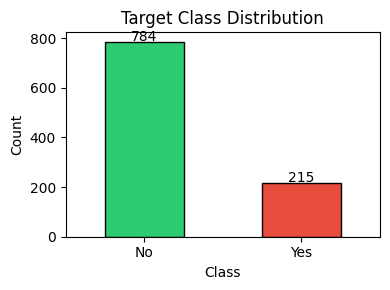

In [32]:
# ── 1.5  Class distribution ───────────────────────────────────────────────────
counts = df['Target'].value_counts()
print('Class counts:')
print(counts)
print(f'\nClass balance (Yes %): {counts["Yes"]/len(df)*100:.1f}%')

fig, ax = plt.subplots(figsize=(4, 3))
counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', ax=ax)
ax.set_title('Target Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height() + 5),
                ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

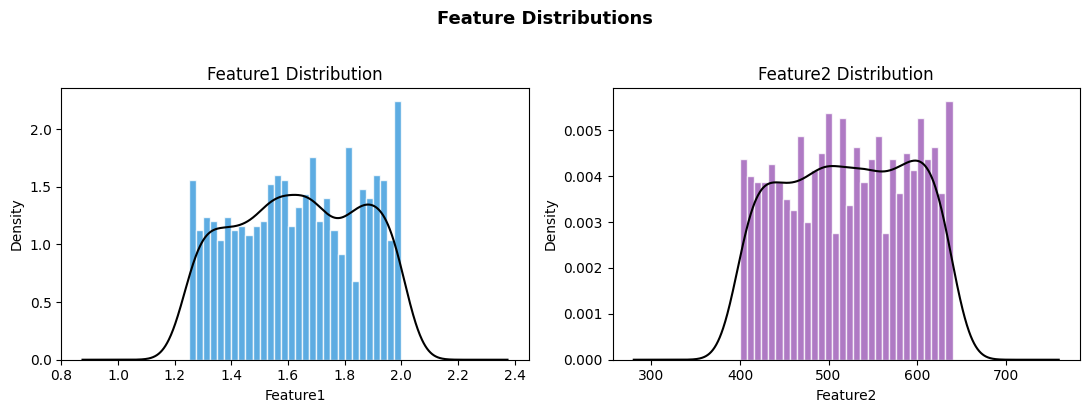

In [33]:
# ── 1.6  Feature distributions (histograms + KDE) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat, color in zip(axes, ['Feature1', 'Feature2'], ['#3498db', '#9b59b6']):
    df[feat].plot(kind='hist', bins=30, color=color, edgecolor='white',
                  alpha=0.8, ax=ax, density=True)
    df[feat].plot(kind='kde', ax=ax, color='black', linewidth=1.5)
    ax.set_title(f'{feat} Distribution')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
plt.suptitle('Feature Distributions', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

/tmp/ipykernel_431/2183286621.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=feat, palette=palette, ax=ax, width=0.5)
/tmp/ipykernel_431/2183286621.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=feat, palette=palette, ax=ax, width=0.5)


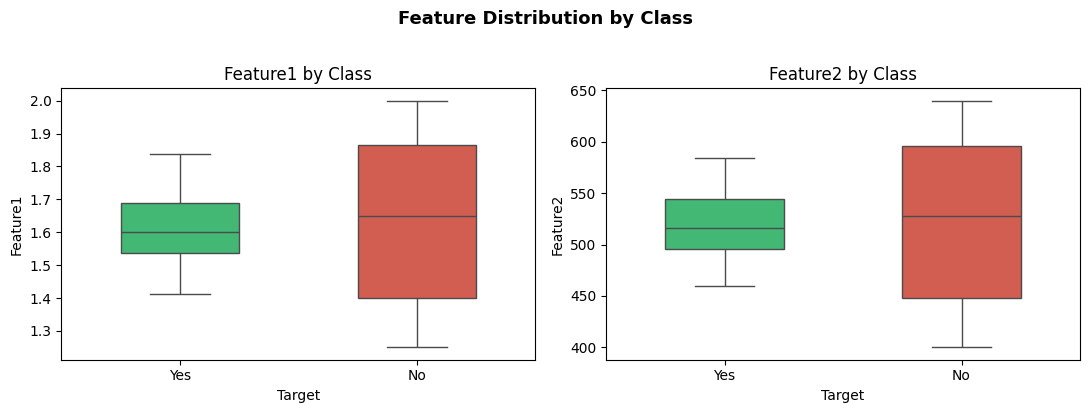

In [34]:
# ── 1.7  Feature distributions by class (box plots) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
palette = {'No': '#e74c3c', 'Yes': '#2ecc71'}
for ax, feat in zip(axes, ['Feature1', 'Feature2']):
    sns.boxplot(data=df, x='Target', y=feat, palette=palette, ax=ax, width=0.5)
    ax.set_title(f'{feat} by Class')
    ax.set_xlabel('Target')
plt.suptitle('Feature Distribution by Class', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_by_class.png', dpi=150)
plt.show()

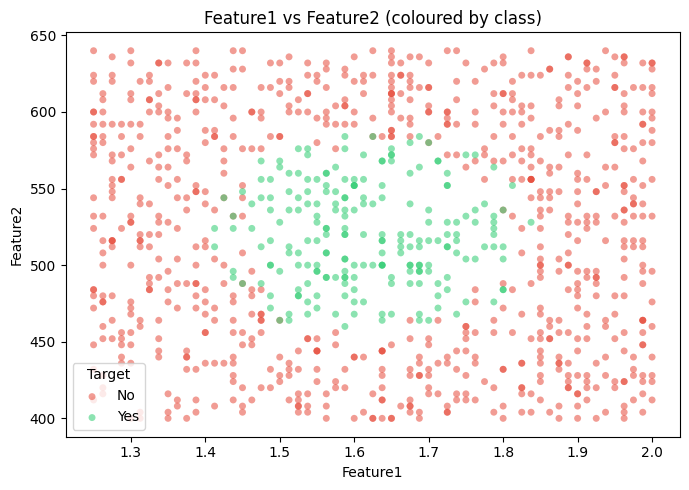

In [35]:
# ── 1.8  Scatter plot of both features, coloured by class ─────────────────────
palette = {'No': '#e74c3c', 'Yes': '#2ecc71'}
fig, ax = plt.subplots(figsize=(7, 5))
for label, grp in df.groupby('Target'):
    ax.scatter(grp['Feature1'], grp['Feature2'],
               label=label, color=palette[label], alpha=0.55, edgecolors='none', s=25)
ax.set_xlabel('Feature1')
ax.set_ylabel('Feature2')
ax.set_title('Feature1 vs Feature2 (coloured by class)')
ax.legend(title='Target')
plt.tight_layout()
plt.savefig('scatter_by_class.png', dpi=150)
plt.show()

In [36]:
# ── 2.1  Prepare feature matrix and label vector ──────────────────────────────
X = df[['Feature1', 'Feature2']].values
y = (df['Target'] == 'Yes').astype(int).values    # Yes → 1,  No → 0
feature_names = ['Feature1', 'Feature2']

print(f'X shape: {X.shape}')
print(f'y distribution: 0 (No) = {(y==0).sum()}, 1 (Yes) = {(y==1).sum()}')

X shape: (999, 2)
y distribution: 0 (No) = 784, 1 (Yes) = 215


In [37]:
# ── 2.2  Train / Test split (80/20, stratified) ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print(f'Train class dist.: No={( y_train==0).sum()}, Yes={(y_train==1).sum()}')
print(f'Test  class dist.: No={( y_test==0).sum()},  Yes={(y_test==1).sum()}')

Training samples : 799
Test samples     : 200
Train class dist.: No=627, Yes=172
Test  class dist.: No=157,  Yes=43


In [38]:
# ── 2.3  Feature scaling ──────────────────────────────────────────────────────
# Logistic Regression is sensitive to feature scale (Feature2 is ~100× larger)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Training-set statistics after scaling:')
print(f'  Feature1 mean={X_train_sc[:,0].mean():.4f}, std={X_train_sc[:,0].std():.4f}')
print(f'  Feature2 mean={X_train_sc[:,1].mean():.4f}, std={X_train_sc[:,1].std():.4f}')

Training-set statistics after scaling:
  Feature1 mean=-0.0000, std=1.0000
  Feature2 mean=0.0000, std=1.0000


In [39]:
# ── 2.4  Train Logistic Regression ───────────────────────────────────────────
log_reg = LogisticRegression(C=1.0, max_iter=1000, random_state=42,
                             class_weight='balanced')   # handle mild imbalance
log_reg.fit(X_train_sc, y_train)

print('=== Learned Model Parameters ===')
print(f'Intercept (bias)        : {log_reg.intercept_[0]:.4f}')
for name, coef in zip(feature_names, log_reg.coef_[0]):
    print(f'Coefficient ({name:8s}) : {coef:.4f}')

=== Learned Model Parameters ===
Intercept (bias)        : -0.0044
Coefficient (Feature1) : -0.1460
Coefficient (Feature2) : 0.0117


In [42]:
# ── 2.5  Cross-validation (5-fold stratified) ─────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scale within each fold using a pipeline to avoid leakage
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, max_iter=1000,
                                  random_state=42, class_weight='balanced'))
])

cv_acc  = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
cv_roc  = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')

print(f'5-Fold CV Accuracy  : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}')
print(f'5-Fold CV ROC-AUC   : {cv_roc.mean():.4f}  ± {cv_roc.std():.4f}')

5-Fold CV Accuracy  : 0.5215  ± 0.0325
5-Fold CV ROC-AUC   : 0.5279  ± 0.0267


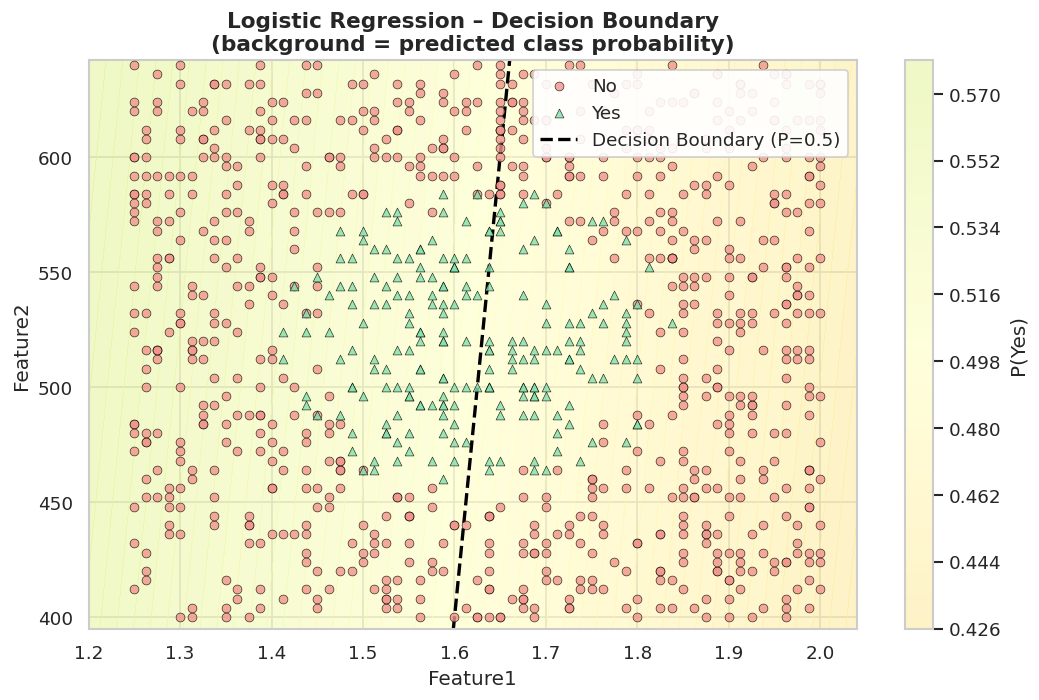

Decision boundary plot saved as decision_boundary.png


In [43]:
# ── 3.1  Decision Boundary (in original feature space) ───────────────────────
# Build a dense mesh in original space, scale it, then predict class probability
h = 0.01          # mesh step
x1_min, x1_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05
x2_min, x2_max = X[:, 1].min() - 5,    X[:, 1].max() + 5

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, h),
    np.arange(x2_min, x2_max, (x2_max - x2_min) / ((x1_max - x1_min) / h))
)
mesh_input = np.c_[xx1.ravel(), xx2.ravel()]
mesh_scaled = scaler.transform(mesh_input)
Z = log_reg.predict(mesh_scaled).reshape(xx1.shape)
Z_prob = log_reg.predict_proba(mesh_scaled)[:, 1].reshape(xx1.shape)

# Colours
palette = {0: '#f1948a', 1: '#82e0aa'}   # red=No, green=Yes

fig, ax = plt.subplots(figsize=(9, 6))

# Probability contour fill
contourf = ax.contourf(xx1, xx2, Z_prob, levels=50,
                        cmap='RdYlGn', alpha=0.55, vmin=0, vmax=1)
fig.colorbar(contourf, ax=ax, label='P(Yes)')

# Hard decision boundary (P = 0.5)
ax.contour(xx1, xx2, Z_prob, levels=[0.5],
           colors='black', linewidths=2.0, linestyles='--')

# Original data points
for label, marker in [(0, 'o'), (1, '^')]:
    mask = (y == label)
    ax.scatter(X[mask, 0], X[mask, 1],
               c=palette[label], edgecolors='black', linewidths=0.4,
               s=28, alpha=0.8, marker=marker,
               label='No' if label == 0 else 'Yes', zorder=3)

# Legend items
boundary_line = plt.Line2D([0], [0], color='black', linestyle='--', linewidth=2,
                            label='Decision Boundary (P=0.5)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [boundary_line], labels + ['Decision Boundary (P=0.5)'],
          loc='upper right', framealpha=0.9)

ax.set_xlabel('Feature1', fontsize=12)
ax.set_ylabel('Feature2', fontsize=12)
ax.set_title('Logistic Regression – Decision Boundary\n(background = predicted class probability)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150)
plt.show()

print('Decision boundary plot saved as decision_boundary.png')

In [44]:
# ── 4.1  Predictions on the held-out test set ─────────────────────────────────
y_pred      = log_reg.predict(X_test_sc)
y_pred_prob = log_reg.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'Test ROC-AUC  : {auc:.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

Test Accuracy : 0.5550  (55.50%)
Test ROC-AUC  : 0.5392

=== Classification Report ===
              precision    recall  f1-score   support

      No (0)       0.85      0.53      0.65       157
     Yes (1)       0.27      0.65      0.39        43

    accuracy                           0.56       200
   macro avg       0.56      0.59      0.52       200
weighted avg       0.72      0.56      0.59       200



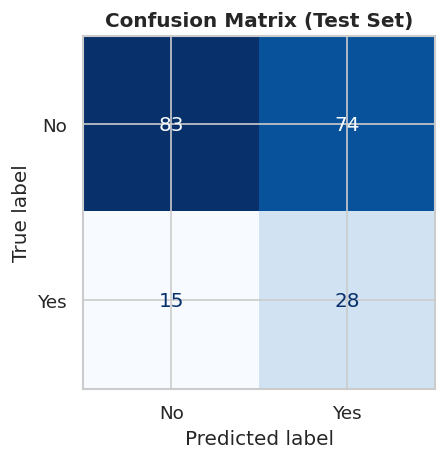

True Negatives  (TN): 83
False Positives (FP): 74
False Negatives (FN): 15
True Positives  (TP): 28


In [45]:
# ── 4.2  Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives  (TP): {tp}')

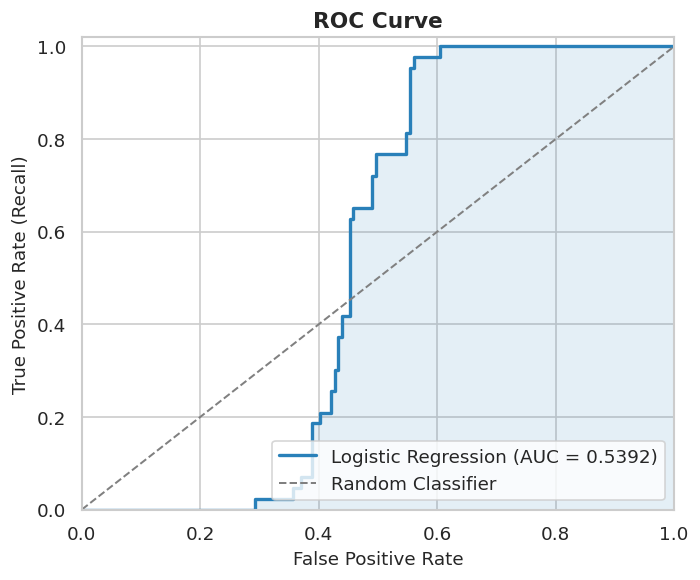

In [46]:
# ── 4.3  ROC Curve ────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#2980b9', lw=2.0, label=f'Logistic Regression (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1.2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.12, color='#2980b9')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [47]:
# ── 4.4  Performance Summary Table ───────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

prec   = precision_score(y_test, y_pred)
rec    = recall_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred)

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Yes)', 'Recall (Yes)', 'F1-Score (Yes)',
               'ROC-AUC',
               '5-Fold CV Accuracy', '5-Fold CV ROC-AUC'],
    'Value' : [f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}',
               f'{auc:.4f}',
               f'{cv_acc.mean():.4f} ± {cv_acc.std():.4f}',
               f'{cv_roc.mean():.4f} ± {cv_roc.std():.4f}']
})
print('=== Model Performance Summary ===')
print(summary.to_string(index=False))

=== Model Performance Summary ===
            Metric           Value
          Accuracy          0.5550
   Precision (Yes)          0.2745
      Recall (Yes)          0.6512
    F1-Score (Yes)          0.3862
           ROC-AUC          0.5392
5-Fold CV Accuracy 0.5215 ± 0.0325
 5-Fold CV ROC-AUC 0.5279 ± 0.0267
